In [14]:
import pandas as pd
import numpy as np
from scipy.ndimage import median_filter
import re
import torch
from sklearn.decomposition import PCA
import math
import matplotlib.pyplot as plt
import seaborn as sns
from bfmtool.utils import get_bfm_columns
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import random

In [15]:
def set_seed(seed):
    """Sets the seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # These two settings are required for full reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42  
set_seed(SEED)

In [16]:
ENVIRONMENT = 'open'

df = pd.read_csv('Cleaned and combined/bfm_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df[df.environment == ENVIRONMENT]
df

,session_id,environment,subject,activity,timestamp,receiver_address,destination_address,transmitter_address,source_address,SCIDX_-122_Ratio_Mag,...,SCIDX_113_Ratio_Phase,SCIDX_114_Ratio_Phase,SCIDX_115_Ratio_Phase,SCIDX_116_Ratio_Phase,SCIDX_117_Ratio_Phase,SCIDX_118_Ratio_Phase,SCIDX_119_Ratio_Phase,SCIDX_120_Ratio_Phase,SCIDX_121_Ratio_Phase,SCIDX_122_Ratio_Phase
95978,20251024_083217,open,kenny,walking,2025-10-24 00:30:42.716808081+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.472466
95979,20251024_083217,open,kenny,walking,2025-10-24 00:30:42.814357996+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.509282,0.509282,0.509282,0.509282,0.509282,0.509282,0.497010,0.497010,0.509282,0.497010
95980,20251024_083217,open,kenny,walking,2025-10-24 00:30:42.911747932+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,18.089884,...,0.509282,0.497010,0.497010,0.497010,0.509282,0.509282,0.497010,0.497010,0.497010,0.484738
95981,20251024_083217,open,kenny,walking,2025-10-24 00:30:43.008847952+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.472466,0.484738,0.484738,0.472466
95982,20251024_083217,open,kenny,walking,2025-10-24 00:30:43.107568026+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.497010,0.497010,0.484738,0.484738,0.484738,0.484738,0.484738,0.472466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143209,20251024_100806,open,collin,standing,2025-10-24 02:08:02.887542009+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738
143210,20251024_100806,open,collin,standing,2025-10-24 02:08:02.985613108+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738
143211,20251024_100806,open,collin,standing,2025-10-24 02:08:03.084455013+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.497010,0.484738
143212,20251024_100806,open,collin,standing,2025-10-24 02:08:03.180236101+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,fa:67:e1:d3:6d:60,fa:67:e1:d3:6d:60,14.793373,...,0.484738,0.484738,0.484738,0.484738,0.484738,0.484738,0.497010,0.497010,0.497010,0.484738


In [17]:
def median_filter_df(df, cols, window_size = 9):
    filtered_df = df.copy()
    
    for ses_id in df['session_id'].unique():
        filtered_data = median_filter(
            df.loc[df.session_id == ses_id, cols], 
            size = (window_size, 1),
            mode = 'nearest'
        )
        filtered_df.loc[df.session_id == ses_id, cols] = filtered_data

    return filtered_df

mag_col = get_bfm_columns(df)['mag_col']
phase_col = get_bfm_columns(df)['phase_col']

df = median_filter_df(df, mag_col + phase_col)


In [18]:
TRAIN_SUBJECTS = ['matthew', 'ivan', 'collin', 'abel']
VALID_SUBJECTS = ['kenny']
TEST_SUBJECTS = ['kenny']

df_train = df.loc[df.subject.isin(TRAIN_SUBJECTS)].copy()
df_valid = df.loc[df.subject.isin(VALID_SUBJECTS)].copy()
df_test = df.loc[df.subject.isin(TEST_SUBJECTS)].copy()


In [19]:
N_COMPONENTS = 5

pca = PCA(n_components = N_COMPONENTS)
pca_train = pca.fit_transform(df_train[mag_col + phase_col])
pca_valid = pca.transform(df_valid[mag_col + phase_col])
pca_test = pca.transform(df_test[mag_col + phase_col])

pca_cols = [f'pca{i}' for i in range(N_COMPONENTS)]

df_train[pca_cols] = pca_train
df_valid[pca_cols] = pca_valid
df_test[pca_cols] = pca_test

df_train.drop(mag_col + phase_col, axis = 1, inplace = True)
df_valid.drop(mag_col + phase_col, axis = 1, inplace = True)
df_test.drop(mag_col + phase_col, axis = 1, inplace = True)

In [20]:
def minus_ma(df, cols, window_size = 20):
    df = df.copy()
    
    for ses_id in df['session_id'].unique():
        
        moving_average = df.loc[df.session_id == ses_id, cols].rolling(window=window_size, min_periods=1).mean()
        # moving_std = df.loc[df.session_id == ses_id, cols].rolling(window=window_size, min_periods=1).std()
        # moving_std = df.loc[df.session_id == ses_id, mag_col + phase_col].rolling(window=window_size, min_periods=window_size).std()
        df.loc[df.session_id == ses_id, cols] -= moving_average
        # df.loc[df.session_id == ses_id, cols] /= moving_std
        
        # df.loc[df.session_id == ses_id, cols] /= moving_std

    return df

def divide_moving_std(df, cols, window_size = 101):
    df = df.copy()
    for ses_id in df['session_id'].unique():
        moving_std = df.loc[df.session_id == ses_id, cols].rolling(window=window_size, min_periods=window_size).std()
        
        df.loc[df.session_id == ses_id, cols] /= moving_std
    df.dropna(inplace = True)
    return df

def rolling_z(df, cols, mean_window = 20, std_window = 101):
    df = minus_ma(df, cols, mean_window)
    df = divide_moving_std(df, cols, std_window)
    return df

In [21]:
df_train = rolling_z(df_train, pca_cols)
df_valid = rolling_z(df_valid, pca_cols)
df_test = rolling_z(df_test, pca_cols)

In [22]:
class TimeSeriesDataset(Dataset):
    """
    Creates a PyTorch dataset for multi-channel time-series classification.
    """
    def __init__(self, df: pd.DataFrame, window_size: int, activity_to_idx: dict = None):
        super().__init__()
        
        df = df.sort_values(by=['session_id', 'timestamp'])
        self.window_size = window_size
        
        self.pca_cols = [col for col in df.columns if col.startswith('pca')]
        features_np = df[self.pca_cols].values
        self.features = torch.tensor(features_np, dtype=torch.float32)
        
        # Label Encoding
        if activity_to_idx is None:
            self.activity_to_idx = {activity: i for i, activity in enumerate(df['activity'].unique())}
        else:
            self.activity_to_idx = activity_to_idx
        self.labels = torch.tensor(df['activity'].map(self.activity_to_idx).values, dtype=torch.long)
        
        # Session IDs for boundary checking
        self.session_ids = df['session_id'].values
        
        # Pre-calculate all valid starting indices to avoid cross-session windows
        self.valid_indices = self._get_valid_indices()
        
    def _get_valid_indices(self):
        # This method is unchanged as it only depends on session_id
        valid_indices = []
        unique_session_ids = np.unique(self.session_ids)
        for session_id in unique_session_ids:
            session_indices = np.where(self.session_ids == session_id)[0]
            start_idx, end_idx = session_indices[0], session_indices[-1]
            session_valid_indices = range(start_idx + self.window_size, end_idx + 1)
            valid_indices.extend(session_valid_indices)
        return valid_indices

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_index = self.valid_indices[idx]
        start_window = real_index - self.window_size
        end_window = real_index
        
        # --- MODIFIED: Tensor Shaping for Conv1d ---
        # Slice has shape (window_size, num_features)
        x_slice = self.features[start_window:end_window] 
        # We transpose to (num_features, window_size) as expected by Conv1d
        x = x_slice.T 
        
        y = self.labels[real_index]
        return x, y

class SeparateChannelCNN(nn.Module):
    """
    A 1D CNN that processes each input channel (feature) independently 
    before combining their outputs for a final classification decision.
    
    This architecture is designed to first find temporal patterns within each 
    channel separately.
    """
    def __init__(self, window_size, num_classes, num_features):
        super().__init__()
        self.num_features = num_features
        
        # We create a separate "tower" (a mini-CNN) for each feature.
        # nn.ModuleList is used to properly register all these towers.
        self.towers = nn.ModuleList([self._create_tower(window_size) for _ in range(num_features)])
        
        # The final classifier takes the concatenated output of all towers.
        # Since each tower outputs 1 neuron, the input size is num_features.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def _create_tower(self, window_size):
        """Helper function to create one independent CNN tower."""
        
        # This is the small CNN that processes a single channel.
        # Note: in_channels is always 1 here.
        tower_conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        
        # We need to calculate the flattened size after the convolutions.
        # A dummy forward pass on a single-channel input does the trick.
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, window_size)
            flattened_size = tower_conv(dummy_input).numel()
            
        # The final part of the tower flattens and reduces to a single neuron.
        tower_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1) # Output one neuron
        )
        
        return nn.Sequential(tower_conv, tower_fc)

    def forward(self, x):
        # Input x has shape: (batch_size, num_features, window_size)
        
        # Split the input tensor along the channel dimension.
        # This gives us a list of tensors, each of shape (batch_size, 1, window_size).
        input_channels = torch.split(x, 1, dim=1)
        
        # Process each channel through its dedicated tower.
        channel_outputs = []
        for i in range(self.num_features):
            tower_output = self.towers[i](input_channels[i])
            channel_outputs.append(tower_output)
            
        # Concatenate the single-neuron outputs from all towers.
        # This creates a feature vector of shape (batch_size, num_features).
        combined = torch.cat(channel_outputs, dim=1)
        
        # Pass the combined feature vector to the final classifier.
        logits = self.classifier(combined)
        
        return logits

In [23]:
# --- B. Hyperparameters & Setup ---
WINDOW_SIZE = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

# --- C. Create Datasets and DataLoaders ---
train_dataset = TimeSeriesDataset(df_train, window_size=WINDOW_SIZE)
activity_map = train_dataset.activity_to_idx
num_classes = len(activity_map)

# --- MODIFIED: Dynamically get the number of features ---
NUM_FEATURES = len(train_dataset.pca_cols)

print(f"Detected {NUM_FEATURES} PCA features.")
print(f"Activity mapping: {activity_map}")

valid_dataset = TimeSeriesDataset(df_valid, window_size=WINDOW_SIZE, activity_to_idx=activity_map)
test_dataset = TimeSeriesDataset(df_test, window_size=WINDOW_SIZE, activity_to_idx=activity_map)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# --- D. Initialize Model, Loss, and Optimizer ---
# --- MODIFIED: Pass num_features to the model constructor ---
model = SeparateChannelCNN(
    window_size=WINDOW_SIZE, 
    num_classes=num_classes, 
    num_features=NUM_FEATURES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\nModel Architecture:")
print(model)
print("\n--- Starting Training ---")

# --- E. Training and Validation Loop ---
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_valid_loss = 0
    correct_preds = 0
    total_preds = 0
    with torch.no_grad():
        for features, labels in valid_loader:
            features, labels = features.to(DEVICE), labels.to(DEVICE)
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_preds += labels.size(0)
            correct_preds += (predicted == labels).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_valid_loss = total_valid_loss / len(valid_loader)
    accuracy = (correct_preds / total_preds) * 100
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f} | Valid Acc: {accuracy:.2f}%")

Using device: cpu
Detected 5 PCA features.
Activity mapping: {'walking': 0, 'standing': 1}

Model Architecture:
SeparateChannelCNN(
  (towers): ModuleList(
    (0-4): 5 x Sequential(
      (0): Sequential(
        (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
        (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (3): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
        (4): ReLU()
        (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Flatten(start_dim=1, end_dim=-1)
        (1): Linear(in_features=192, out_features=16, bias=True)
        (2): ReLU()
        (3): Linear(in_features=16, out_features=1, bias=True)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

--- Starting Training -

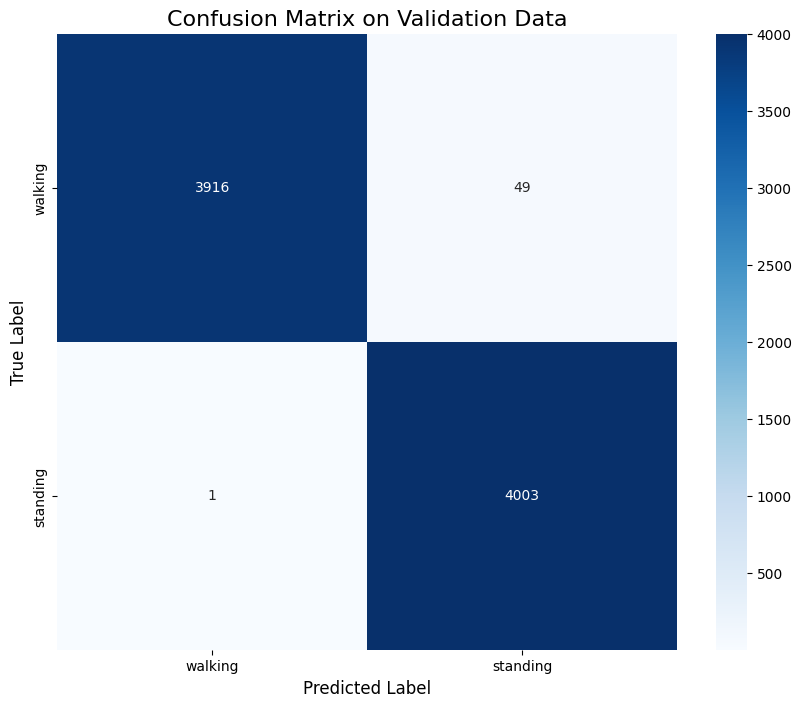

In [24]:
all_predictions = []
all_true_labels = []

model.eval()  # Set the model to evaluation mode (important!)
with torch.no_grad():  # We don't need to calculate gradients here
    for features, labels in valid_loader:
        # Move data to the same device as the model
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Get model outputs (logits)
        outputs = model(features)
        
        # Get the predicted class by finding the index of the max logit
        _, predicted = torch.max(outputs.data, 1)
        
        # Append batch results to our lists
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# 2. Compute the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# 3. Create Class Labels for the Plot
# The matrix is just numbers; we need to label the axes with the actual activity names.
# We'll create an inverted mapping from index to activity name.
idx_to_activity = {v: k for k, v in activity_map.items()}
class_names = [idx_to_activity[i] for i in range(len(idx_to_activity))]


# 4. Plot the Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,      # Show the numbers in the cells
    fmt='d',         # Format as integers
    cmap='Blues',    # Use a blue color scheme
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Confusion Matrix on Validation Data', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

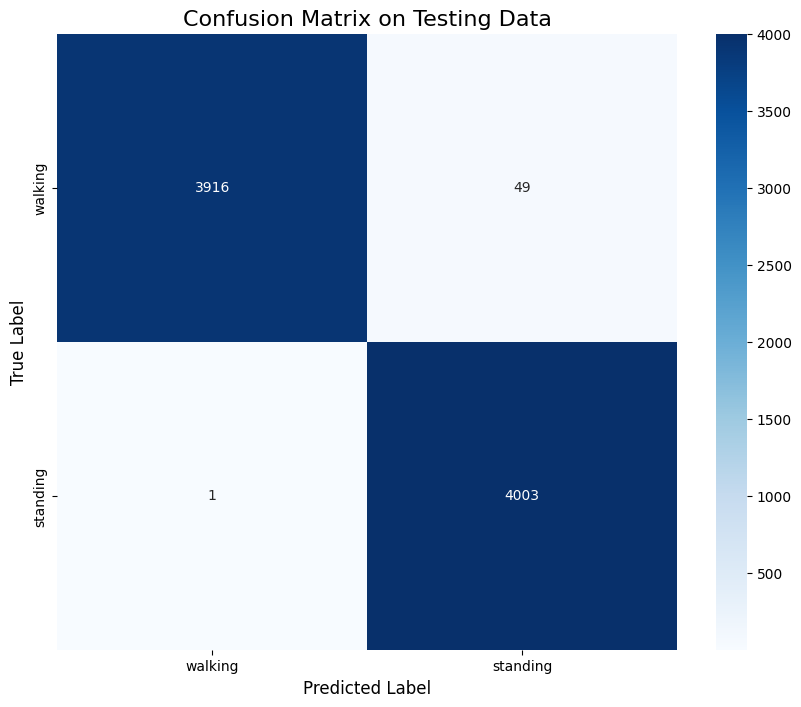

In [25]:
all_predictions = []
all_true_labels = []

model.eval()  # Set the model to evaluation mode (important!)
with torch.no_grad():  # We don't need to calculate gradients here
    for features, labels in test_loader:
        # Move data to the same device as the model
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Get model outputs (logits)
        outputs = model(features)
        
        # Get the predicted class by finding the index of the max logit
        _, predicted = torch.max(outputs.data, 1)
        
        # Append batch results to our lists
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# 2. Compute the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# 3. Create Class Labels for the Plot
# The matrix is just numbers; we need to label the axes with the actual activity names.
# We'll create an inverted mapping from index to activity name.
idx_to_activity = {v: k for k, v in activity_map.items()}
class_names = [idx_to_activity[i] for i in range(len(idx_to_activity))]


# 4. Plot the Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,      # Show the numbers in the cells
    fmt='d',         # Format as integers
    cmap='Blues',    # Use a blue color scheme
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Confusion Matrix on Testing Data', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [26]:
all_preds = []
all_labels = []

model.eval() # Set the model to evaluation mode
with torch.no_grad(): # No need to track gradients
    for features, labels in valid_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Create a results DataFrame
# The key is to use `valid_dataset.valid_indices` which maps the
# sequential output of the dataloader back to the original df's index.
results_df = pd.DataFrame({
    'original_index': valid_dataset.valid_indices,
    'true_label_idx': all_labels,
    'predicted_label_idx': all_preds
})

# 3. Merge results with the original validation data
# We must first sort df_valid exactly as the dataset did.
df_valid_sorted = df_valid.sort_values(by=['session_id', 'timestamp']).reset_index(drop=True)

# Use the original_index to get the metadata (session, subject)
results_df['session_id'] = df_valid_sorted.loc[results_df['original_index'], 'session_id'].values
results_df['subject'] = df_valid_sorted.loc[results_df['original_index'], 'subject'].values

# 4. Identify misclassifications
results_df['misclassified'] = results_df['true_label_idx'] != results_df['predicted_label_idx']
misclassifications_df = results_df[results_df['misclassified']]

# 5. Analyze the errors
if misclassifications_df.empty:
    print("🎉 No misclassifications found on the validation set! The model is perfect.")
else:
    # Count errors per session_id
    session_errors = misclassifications_df['session_id'].value_counts()
    
    # Count errors per subject
    subject_errors = misclassifications_df['subject'].value_counts()

    print("--- Error Analysis Report ---")
    print("\n⚠️ Misclassifications per Session ID:")
    print(session_errors)
    
    print("\n👤 Misclassifications per Subject:")
    print(subject_errors)
    
    # Find the single session and subject with the most errors
    most_problematic_session = session_errors.index[0]
    most_problematic_subject = subject_errors.index[0]
    
    print("\n--- Conclusion ---")
    print(f"The session with the most errors is: '{most_problematic_session}' with {session_errors.iloc[0]} misclassifications.")
    print(f"The subject with the most errors is: '{most_problematic_subject}' with {subject_errors.iloc[0]} misclassifications.")

--- Error Analysis Report ---

⚠️ Misclassifications per Session ID:
session_id
20251024_083217    40
20251024_084310     9
20251024_084836     1
Name: count, dtype: int64

👤 Misclassifications per Subject:
subject
kenny    50
Name: count, dtype: int64

--- Conclusion ---
The session with the most errors is: '20251024_083217' with 40 misclassifications.
The subject with the most errors is: 'kenny' with 50 misclassifications.
